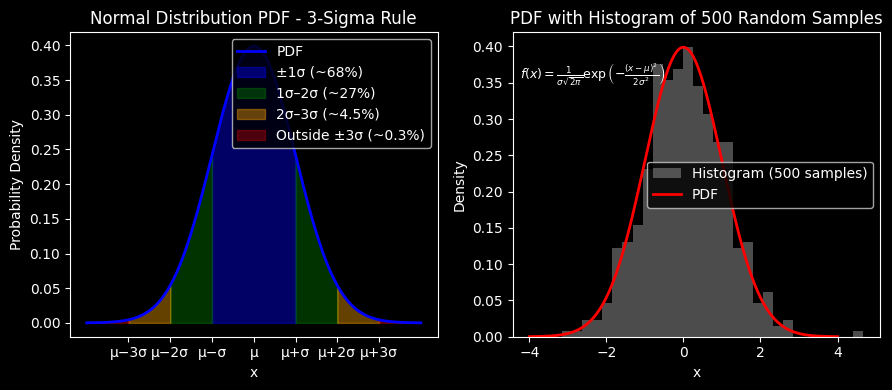

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters (change these and re-run)
mu = 0.0
sigma = 1.0

# Generate data
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)


def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2))


pdf = normal_pdf(x, mu, sigma)
samples = np.random.normal(mu, sigma, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# Left: PDF with 3-sigma regions filled in different colors
ax1.plot(x, pdf, 'b-', linewidth=2, label='PDF')
# ±1σ region (~68%)
x_1 = np.linspace(mu - sigma, mu + sigma, 200)
ax1.fill_between(x_1, 0, normal_pdf(x_1, mu, sigma), color='blue', alpha=0.4, label='±1σ (~68%)')
# 1σ to 2σ regions (~27%)
x_2_low = np.linspace(mu - 2 * sigma, mu - sigma, 200)
x_2_high = np.linspace(mu + sigma, mu + 2 * sigma, 200)
ax1.fill_between(x_2_low, 0, normal_pdf(x_2_low, mu, sigma), color='green', alpha=0.4)
ax1.fill_between(x_2_high, 0, normal_pdf(x_2_high, mu, sigma), color='green', alpha=0.4, label='1σ–2σ (~27%)')
# 2σ to 3σ regions (~4.5%)
x_3_low = np.linspace(mu - 3 * sigma, mu - 2 * sigma, 200)
x_3_high = np.linspace(mu + 2 * sigma, mu + 3 * sigma, 200)
ax1.fill_between(x_3_low, 0, normal_pdf(x_3_low, mu, sigma), color='orange', alpha=0.4)
ax1.fill_between(x_3_high, 0, normal_pdf(x_3_high, mu, sigma), color='orange', alpha=0.4, label='2σ–3σ (~4.5%)')
# Outside ±3σ (~0.3%)
x_tail_low = np.linspace(mu - 4 * sigma, mu - 3 * sigma, 100)
x_tail_high = np.linspace(mu + 3 * sigma, mu + 4 * sigma, 100)
ax1.fill_between(x_tail_low, 0, normal_pdf(x_tail_low, mu, sigma), color='red', alpha=0.3)
ax1.fill_between(x_tail_high, 0, normal_pdf(x_tail_high, mu, sigma), color='red', alpha=0.3,
                 label='Outside ±3σ (~0.3%)')

ax1.set_title('Normal Distribution PDF - 3-Sigma Rule')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.legend(loc='upper right')
# Sigma tick marks
ticks = [mu - 3 * sigma, mu - 2 * sigma, mu - sigma, mu, mu + sigma, mu + 2 * sigma, mu + 3 * sigma]
ax1.set_xticks(ticks)
ax1.set_xticklabels(['μ−3σ', 'μ−2σ', 'μ−σ', 'μ', 'μ+σ', 'μ+2σ', 'μ+3σ'])

# Right: PDF + histogram + formula
ax2.hist(samples, bins=30, density=True, alpha=0.6, color='gray', label='Histogram (500 samples)')
ax2.plot(x, pdf, 'r-', linewidth=2, label='PDF')
ax2.set_title('PDF with Histogram of 500 Random Samples')
ax2.set_xlabel('x')
ax2.set_ylabel('Density')
ax2.legend()

# Normal distribution formula (English)
formula = r'$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$'
ax2.text(0.02, 0.85, formula, transform=ax2.transAxes, fontsize=9)

plt.tight_layout()
plt.show()
